# Fresh Start Effect in Criminal Behavior
## Investigating Heather's Hypothesis: Do Temporal Landmarks Influence Crime Patterns?

**Research Question:** Do premeditated crimes show stronger "Fresh Start Effect" patterns compared to impulsive crimes?

**Background:** The Fresh Start Effect is a psychological phenomenon where people are more motivated to pursue goals around temporal landmarks (Mondays, 1st of month, New Year). This analysis investigates whether this effect applies to criminal behavior, particularly premeditated crimes.

---

### Analysis Structure:
1. Load and prepare data
2. Categorize crimes (Premeditated vs Impulsive)
3. Define temporal landmarks
4. Statistical analysis (Chi-square test)
5. Fresh Start Index calculation
6. Visualizations
7. Machine Learning classification
8. Conclusions

---
## Step 1: Setup and Data Loading

In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from datetime import datetime
import os

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output directory if not exists
os.makedirs('output', exist_ok=True)

print("Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Libraries imported successfully!
Analysis Date: 2026-02-05 15:23


In [12]:
# Load all historical crime data
crime_files = {
    '2019-20': 'data/historical/2019-20-fullyr-data_sa_crime.csv',
    '2020-21': 'data/historical/2020-21_data_sa_crime.csv',
    '2022-23': 'data/historical/2022-23_data_sa_crime (1).csv',
    '2023-24': 'data/historical/data-sa-crime-2023-24-full-fy (1).csv',
    '2025-26 Q1': 'data/historical/data_sa_crime_q1_2025-26-datasa.csv'
}

crime_dfs = []
for year, filepath in crime_files.items():
    try:
        df = pd.read_csv(filepath)
        crime_dfs.append(df)
        print(f"Loaded {year}: {len(df):,} records")
    except Exception as e:
        print(f"Error loading {year}: {e}")

# Combine all data
crime_data = pd.concat(crime_dfs, ignore_index=True)

# Convert date to datetime IMMEDIATELY after loading (before calling min/max)
# This fixes TypeError with mixed str/float types
crime_data['Reported Date'] = pd.to_datetime(
    crime_data['Reported Date'],
    dayfirst=True,  # Handle DD/MM/YYYY format
    errors='coerce'
)

# Drop rows with invalid dates
crime_data = crime_data.dropna(subset=['Reported Date'])

print(f"\nTotal Records: {len(crime_data):,}")
print(f"Date Range: {crime_data['Reported Date'].min().strftime('%Y-%m-%d')} to {crime_data['Reported Date'].max().strftime('%Y-%m-%d')}")

Loaded 2019-20: 95,702 records
Loaded 2020-21: 84,949 records
Loaded 2022-23: 97,078 records
Loaded 2023-24: 99,916 records
Loaded 2025-26 Q1: 22,853 records

Total Records: 400,497
Date Range: 2019-07-01 to 2025-09-30


---
## Step 2: Data Preprocessing

In [13]:
# Extract temporal features
crime_data['Year'] = crime_data['Reported Date'].dt.year
crime_data['Month'] = crime_data['Reported Date'].dt.month
crime_data['Day'] = crime_data['Reported Date'].dt.day
crime_data['Quarter'] = crime_data['Reported Date'].dt.quarter
crime_data['DayOfWeek'] = crime_data['Reported Date'].dt.dayofweek  # 0=Monday
crime_data['DayName'] = crime_data['Reported Date'].dt.day_name()
crime_data['IsWeekend'] = crime_data['DayOfWeek'].isin([5, 6]).astype(int)

print("Temporal features extracted")
print(f"\nData Shape: {crime_data.shape}")
crime_data.head(3)

Temporal features extracted

Data Shape: (400497, 14)


,Reported Date,Suburb - Incident,Postcode - Incident,Offence Level 1 Description,Offence Level 2 Description,Offence Level 3 Description,Offence count,Year,Month,Day,Quarter,DayOfWeek,DayName,IsWeekend
0,2019-07-01,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,FRAUD DECEPTION AND RELATED OFFENCES,Obtain benefit by deception,1.0,2019,7,1,3,0,Monday,0
1,2019-07-01,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,FRAUD DECEPTION AND RELATED OFFENCES,"Other fraud, deception and related offences",1.0,2019,7,1,3,0,Monday,0
2,2019-07-01,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,PROPERTY DAMAGE AND ENVIRONMENTAL,Graffiti,1.0,2019,7,1,3,0,Monday,0


---
## Step 3: Define Temporal Landmarks (Fresh Start Moments)

In [14]:
# Define "Fresh Start" temporal landmarks
crime_data['IsMonday'] = (crime_data['DayOfWeek'] == 0).astype(int)
crime_data['IsFirstOfMonth'] = (crime_data['Day'] == 1).astype(int)
crime_data['IsStartOfQuarter'] = crime_data['Reported Date'].dt.is_quarter_start.astype(int)
crime_data['IsNewYear'] = ((crime_data['Month'] == 1) & (crime_data['Day'] == 1)).astype(int)

# Combined landmark indicator (any fresh start moment)
crime_data['IsLandmark'] = (
    (crime_data['IsMonday'] == 1) | 
    (crime_data['IsFirstOfMonth'] == 1) |
    (crime_data['IsStartOfQuarter'] == 1)
).astype(int)

# Statistics
landmark_days = crime_data['IsLandmark'].sum()
total_days = len(crime_data)
landmark_percentage = (landmark_days / total_days) * 100

print(f"Temporal Landmarks Defined:")
print(f"   - Mondays: {crime_data['IsMonday'].sum():,} records ({crime_data['IsMonday'].sum()/len(crime_data)*100:.1f}%)")
print(f"   - 1st of Month: {crime_data['IsFirstOfMonth'].sum():,} records ({crime_data['IsFirstOfMonth'].sum()/len(crime_data)*100:.1f}%)")
print(f"   - Quarter Starts: {crime_data['IsStartOfQuarter'].sum():,} records ({crime_data['IsStartOfQuarter'].sum()/len(crime_data)*100:.1f}%)")
print(f"   - New Year's Day: {crime_data['IsNewYear'].sum():,} records")
print(f"\nTotal Landmark Days: {landmark_days:,} ({landmark_percentage:.1f}% of all records)")

Temporal Landmarks Defined:
   - Mondays: 64,888 records (16.2%)
   - 1st of Month: 13,418 records (3.4%)
   - Quarter Starts: 4,442 records (1.1%)
   - New Year's Day: 1,196 records

Total Landmark Days: 75,716 (18.9% of all records)


---
## Step 4: Categorize Crimes (Premeditated vs Impulsive)

**Hypothesis:** Premeditated crimes should show stronger Fresh Start patterns than impulsive crimes.

In [15]:
# Examine available crime types
print("Available Crime Types:")
print("\nOffence Level 2 (Main Categories):")
print(crime_data['Offence Level 2 Description'].value_counts())

Available Crime Types:

Offence Level 2 (Main Categories):
Offence Level 2 Description
THEFT AND RELATED OFFENCES              163691
PROPERTY DAMAGE AND ENVIRONMENTAL        69886
ACTS INTENDED TO CAUSE INJURY            68451
SERIOUS CRIMINAL TRESPASS                50652
FRAUD DECEPTION AND RELATED OFFENCES     15490
THEFT                                    10008
OTHER OFFENCES AGAINST THE PERSON         5869
ASSAULT                                   4617
PROPERTY DAMAGE                           3521
SEXUAL ASSAULT AND RELATED OFFENCES       3359
ROBBERY AND RELATED OFFENCES              2715
FRAUD AND RELATED OFFENCES                1061
HARM OR ENDANGER PERSONS                   596
SEXUAL OFFENCES                            249
ROBBERY, BLACKMAIL, AND EXTORTION          168
HOMICIDE AND RELATED OFFENCES              158
HOMICIDE                                     6
Name: count, dtype: int64


In [16]:
# Categorize crimes based on planning/premeditation

# PREMEDITATED CRIMES (require planning, deliberate)
premeditated_crimes = [
    'FRAUD DECEPTION AND RELATED OFFENCES',
    'SERIOUS CRIMINAL TRESPASS',  # Burglary - often planned
    'UNLAWFUL ENTRY WITH INTENT',  # Breaking and entering
    'ROBBERY AND RELATED OFFENCES',  # Often planned
    'THEFT AND RELATED OFFENCES'  # Shoplifting, theft often planned
]

# IMPULSIVE CRIMES (spontaneous, emotional, situational)
impulsive_crimes = [
    'ACTS INTENDED TO CAUSE INJURY',  # Assault - often heat of moment
    'DANGEROUS OR NEGLIGENT ACTS ENDANGERING PERSONS',
    'SEXUAL ASSAULT AND RELATED OFFENCES',  # Can be opportunistic
    'ABDUCTION AND RELATED OFFENCES'
]

# Create categorization
def categorize_crime(crime_type):
    if crime_type in premeditated_crimes:
        return 'Premeditated'
    elif crime_type in impulsive_crimes:
        return 'Impulsive'
    else:
        return 'Other'

crime_data['Crime_Category'] = crime_data['Offence Level 2 Description'].apply(categorize_crime)

# Statistics
category_counts = crime_data.groupby('Crime_Category')['Offence count'].sum().sort_values(ascending=False)

print("Crimes Categorized:")
print("\nTotal Offences by Category:")
for category, count in category_counts.items():
    percentage = (count / crime_data['Offence count'].sum()) * 100
    print(f"   - {category}: {count:,} offences ({percentage:.1f}%)")

print("\nPremeditated Crime Types:")
for crime in premeditated_crimes:
    count = crime_data[crime_data['Offence Level 2 Description'] == crime]['Offence count'].sum()
    print(f"   - {crime}: {count:,}")

print("\nImpulsive Crime Types:")
for crime in impulsive_crimes:
    count = crime_data[crime_data['Offence Level 2 Description'] == crime]['Offence count'].sum()
    print(f"   - {crime}: {count:,}")

Crimes Categorized:

Total Offences by Category:
   - Premeditated: 284,620.0 offences (57.8%)
   - Other: 118,375.0 offences (24.0%)
   - Impulsive: 89,713.0 offences (18.2%)

Premeditated Crime Types:
   - FRAUD DECEPTION AND RELATED OFFENCES: 18,572.0
   - SERIOUS CRIMINAL TRESPASS: 55,866.0
   - UNLAWFUL ENTRY WITH INTENT: 0.0
   - ROBBERY AND RELATED OFFENCES: 2,978.0
   - THEFT AND RELATED OFFENCES: 207,204.0

Impulsive Crime Types:
   - ACTS INTENDED TO CAUSE INJURY: 80,669.0
   - DANGEROUS OR NEGLIGENT ACTS ENDANGERING PERSONS: 0.0
   - SEXUAL ASSAULT AND RELATED OFFENCES: 9,044.0
   - ABDUCTION AND RELATED OFFENCES: 0.0


---
## Step 5: Statistical Analysis - Testing the Hypothesis

**Null Hypothesis (H0):** Crime patterns are uniform across temporal landmarks (no Fresh Start Effect)

**Alternative Hypothesis (H1):** Premeditated crimes show higher occurrence on temporal landmarks

In [17]:
# Analysis 1: Monday Effect
print("ANALYSIS 1: MONDAY EFFECT\n" + "="*60)

# Aggregate by day of week
dow_analysis = crime_data.groupby(['DayName', 'DayOfWeek', 'Crime_Category'])['Offence count'].sum().reset_index()
dow_pivot = dow_analysis.pivot(index=['DayName', 'DayOfWeek'], columns='Crime_Category', values='Offence count').fillna(0)

# Sort by DayOfWeek to get Mon-Sun order
dow_pivot = dow_pivot.sort_index(level='DayOfWeek')

print("\nTotal Crimes by Day of Week:")
print(dow_pivot)

# Calculate Monday vs Other Days for each category
print("\nMonday vs Other Weekdays Comparison:")

for category in ['Premeditated', 'Impulsive']:
    if category in dow_pivot.columns:
        monday_crimes = dow_pivot.loc[dow_pivot.index.get_level_values('DayOfWeek') == 0, category].values[0]
        weekday_crimes = dow_pivot.loc[(dow_pivot.index.get_level_values('DayOfWeek') >= 1) & 
                                       (dow_pivot.index.get_level_values('DayOfWeek') <= 4), category].sum()
        avg_weekday = weekday_crimes / 4  # Average across Tue-Fri
        
        monday_effect = ((monday_crimes - avg_weekday) / avg_weekday) * 100
        
        print(f"\n{category} Crimes:")
        print(f"   - Monday: {monday_crimes:,.0f}")
        print(f"   - Avg Weekday (Tue-Fri): {avg_weekday:,.0f}")
        print(f"   - Monday Effect: {monday_effect:+.1f}%")

ANALYSIS 1: MONDAY EFFECT

Total Crimes by Day of Week:
Crime_Category       Impulsive    Other  Premeditated
DayName   DayOfWeek                                  
Monday    0            13229.0  19930.0       46811.0
Tuesday   1            12359.0  17537.0       42913.0
Wednesday 2            12477.0  16559.0       42030.0
Thursday  3            12290.0  16327.0       41266.0
Friday    4            12897.0  16755.0       41833.0
Saturday  5            12993.0  15651.0       35292.0
Sunday    6            13468.0  15616.0       34475.0

Monday vs Other Weekdays Comparison:

Premeditated Crimes:
   - Monday: 46,811
   - Avg Weekday (Tue-Fri): 42,010
   - Monday Effect: +11.4%

Impulsive Crimes:
   - Monday: 13,229
   - Avg Weekday (Tue-Fri): 12,506
   - Monday Effect: +5.8%


In [18]:
# Analysis 2: Chi-Square Test for Independence
print("\nANALYSIS 2: CHI-SQUARE TEST\n" + "="*60)
print("Testing if crime category is independent of Monday status...\n")

# Create contingency table
contingency_data = crime_data[crime_data['Crime_Category'].isin(['Premeditated', 'Impulsive'])].copy()
contingency_table = pd.crosstab(
    contingency_data['Crime_Category'],
    contingency_data['IsMonday'],
    values=contingency_data['Offence count'],
    aggfunc='sum'
)
contingency_table.columns = ['Other Days', 'Monday']

print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistics:")
print(f"   - Chi-squared statistic: {chi2:.2f}")
print(f"   - p-value: {p_value:.6f}")
print(f"   - Degrees of freedom: {dof}")
print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (alpha = 0.05)")

if p_value < 0.05:
    print("   We REJECT the null hypothesis")
    print("   Crime category and Monday status are NOT independent")
    print("   The hypothesis is SUPPORTED!")
else:
    print("   We FAIL TO REJECT the null hypothesis")
    print("   No significant Fresh Start Effect detected")


ANALYSIS 2: CHI-SQUARE TEST
Testing if crime category is independent of Monday status...

Contingency Table:
                Other Days   Monday
Crime_Category                     
Impulsive          76484.0  13229.0
Premeditated      237809.0  46811.0

Chi-Square Statistics:
   - Chi-squared statistic: 146.42
   - p-value: 0.000000
   - Degrees of freedom: 1

Result: SIGNIFICANT (alpha = 0.05)
   We REJECT the null hypothesis
   Crime category and Monday status are NOT independent
   The hypothesis is SUPPORTED!


In [19]:
# Analysis 3: First of Month Effect
print("\nANALYSIS 3: FIRST OF MONTH EFFECT\n" + "="*60)

# Compare 1st vs other days
month_analysis = crime_data.groupby(['IsFirstOfMonth', 'Crime_Category'])['Offence count'].sum().reset_index()
month_pivot = month_analysis.pivot(index='IsFirstOfMonth', columns='Crime_Category', values='Offence count').fillna(0)
month_pivot.index = ['Other Days', '1st of Month']

print("Crimes on 1st of Month vs Other Days:")
print(month_pivot)

print("\nFirst of Month Effect:")
for category in ['Premeditated', 'Impulsive']:
    if category in month_pivot.columns:
        first_crimes = month_pivot.loc['1st of Month', category]
        other_crimes = month_pivot.loc['Other Days', category]
        
        # Calculate per-day average
        num_first_days = crime_data['IsFirstOfMonth'].sum()
        num_other_days = len(crime_data) - num_first_days
        
        avg_first = first_crimes / num_first_days if num_first_days > 0 else 0
        avg_other = other_crimes / num_other_days if num_other_days > 0 else 0
        
        effect = ((avg_first - avg_other) / avg_other) * 100 if avg_other > 0 else 0
        
        print(f"\n{category}:")
        print(f"   - Avg crimes on 1st: {avg_first:.2f}")
        print(f"   - Avg crimes on other days: {avg_other:.2f}")
        print(f"   - Effect: {effect:+.1f}%")


ANALYSIS 3: FIRST OF MONTH EFFECT
Crimes on 1st of Month vs Other Days:
Crime_Category  Impulsive     Other  Premeditated
Other Days        86593.0  114373.0      275316.0
1st of Month       3120.0    4002.0        9304.0

First of Month Effect:

Premeditated:
   - Avg crimes on 1st: 0.69
   - Avg crimes on other days: 0.71
   - Effect: -2.5%

Impulsive:
   - Avg crimes on 1st: 0.23
   - Avg crimes on other days: 0.22
   - Effect: +3.9%


---
## Step 6: Fresh Start Index Calculation

**Fresh Start Index (FSI):** Measures strength of temporal landmark effect
- **FSI = 0:** No effect (uniform distribution)
- **FSI > 0:** Positive effect (crimes increase at landmarks)
- **FSI < 0:** Negative effect (crimes decrease at landmarks)

In [20]:
def calculate_fresh_start_index(crime_type, crime_category_filter=None):
    """
    Calculate Fresh Start Index for a specific crime type or category
    
    FSI = (Actual Landmark Proportion - Expected Proportion) / Expected Proportion
    
    Both proportions are computed using Offence count sums (not row counts)
    so that the units match.
    """
    # Filter data
    if crime_category_filter:
        mask = crime_data['Crime_Category'] == crime_category_filter
    else:
        mask = crime_data['Offence Level 2 Description'] == crime_type
    
    subset = crime_data[mask].copy()
    
    if len(subset) == 0:
        return None
    
    # Calculate landmark crimes
    landmark_crimes = subset[subset['IsLandmark'] == 1]['Offence count'].sum()
    total_crimes = subset['Offence count'].sum()
    
    # Calculate proportions
    actual_proportion = landmark_crimes / total_crimes if total_crimes > 0 else 0
    
    # Expected proportion: fraction of total offences that fall on landmark days
    # Uses Offence count sums (same unit as actual_proportion), not raw row counts
    landmark_crimes_all = crime_data.loc[crime_data['IsLandmark'] == 1, 'Offence count'].sum()
    total_crimes_all = crime_data['Offence count'].sum()
    expected_proportion = landmark_crimes_all / total_crimes_all
    
    # Calculate FSI
    if expected_proportion > 0:
        fsi = (actual_proportion - expected_proportion) / expected_proportion
    else:
        fsi = 0
    
    return {
        'FSI': fsi,
        'Actual_Proportion': actual_proportion,
        'Expected_Proportion': expected_proportion,
        'Total_Crimes': total_crimes,
        'Landmark_Crimes': landmark_crimes
    }

print("FRESH START INDEX CALCULATION\n" + "="*60)

# Calculate FSI for categories
print("\nFSI by Crime Category:")
fsi_by_category = {}
for category in ['Premeditated', 'Impulsive', 'Other']:
    result = calculate_fresh_start_index(None, category)
    if result:
        fsi_by_category[category] = result['FSI']
        print(f"\n{category} Crimes:")
        print(f"   - Fresh Start Index: {result['FSI']:+.4f}")
        print(f"   - Total crimes: {result['Total_Crimes']:,.0f}")
        print(f"   - Crimes on landmarks: {result['Landmark_Crimes']:,.0f}")
        print(f"   - Actual proportion: {result['Actual_Proportion']:.2%}")
        print(f"   - Expected proportion: {result['Expected_Proportion']:.2%}")
        
        if result['FSI'] > 0:
            effect_pct = result['FSI'] * 100
            print(f"   {effect_pct:+.1f}% MORE crimes on landmarks than expected")
        elif result['FSI'] < 0:
            effect_pct = abs(result['FSI']) * 100
            print(f"   {effect_pct:.1f}% FEWER crimes on landmarks than expected")

FRESH START INDEX CALCULATION

FSI by Crime Category:

Premeditated Crimes:
   - Fresh Start Index: +0.0106
   - Total crimes: 284,620
   - Crimes on landmarks: 54,436
   - Actual proportion: 19.13%
   - Expected proportion: 18.93%
   +1.1% MORE crimes on landmarks than expected

Impulsive Crimes:
   - Fresh Start Index: -0.0698
   - Total crimes: 89,713
   - Crimes on landmarks: 15,793
   - Actual proportion: 17.60%
   - Expected proportion: 18.93%
   7.0% FEWER crimes on landmarks than expected

Other Crimes:
   - Fresh Start Index: +0.0274
   - Total crimes: 118,375
   - Crimes on landmarks: 23,017
   - Actual proportion: 19.44%
   - Expected proportion: 18.93%
   +2.7% MORE crimes on landmarks than expected


In [21]:
# Calculate FSI for specific crime types
print("\nFSI by Specific Crime Type:")

fsi_results = []

all_crime_types = premeditated_crimes + impulsive_crimes

for crime_type in all_crime_types:
    result = calculate_fresh_start_index(crime_type, None)
    if result:
        category = 'Premeditated' if crime_type in premeditated_crimes else 'Impulsive'
        fsi_results.append({
            'Crime Type': crime_type,
            'Category': category,
            'FSI': result['FSI'],
            'Total Crimes': result['Total_Crimes']
        })

# Create DataFrame and sort
fsi_df = pd.DataFrame(fsi_results).sort_values('FSI', ascending=False)

print("\nRanked by Fresh Start Index:")
print(fsi_df.to_string(index=False))

# Summary — use volume-weighted average so high-volume crime types are not
# diluted by low-volume ones (e.g. ROBBERY at 2,978 crimes vs THEFT at 207,204)
print("\nKEY FINDINGS:")
prem_sub = fsi_df[fsi_df['Category'] == 'Premeditated']
imp_sub  = fsi_df[fsi_df['Category'] == 'Impulsive']

premeditated_avg_fsi = np.average(prem_sub['FSI'], weights=prem_sub['Total Crimes'])
impulsive_avg_fsi    = np.average(imp_sub['FSI'],  weights=imp_sub['Total Crimes'])

print(f"   - Weighted Avg FSI (Premeditated): {premeditated_avg_fsi:+.4f}")
print(f"   - Weighted Avg FSI (Impulsive): {impulsive_avg_fsi:+.4f}")
print(f"   - Difference: {(premeditated_avg_fsi - impulsive_avg_fsi):+.4f}")

if premeditated_avg_fsi > impulsive_avg_fsi:
    print(f"\nHYPOTHESIS SUPPORTED! Premeditated crimes show stronger Fresh Start Effect!")
else:
    print(f"\nHypothesis not strongly supported by FSI data")


FSI by Specific Crime Type:

Ranked by Fresh Start Index:
                          Crime Type     Category       FSI  Total Crimes
           SERIOUS CRIMINAL TRESPASS Premeditated  0.047598       55866.0
          THEFT AND RELATED OFFENCES Premeditated  0.002811      207204.0
FRAUD DECEPTION AND RELATED OFFENCES Premeditated -0.003354       18572.0
 SEXUAL ASSAULT AND RELATED OFFENCES    Impulsive -0.024886        9044.0
        ROBBERY AND RELATED OFFENCES Premeditated -0.054281        2978.0
       ACTS INTENDED TO CAUSE INJURY    Impulsive -0.074854       80669.0

KEY FINDINGS:
   - Weighted Avg FSI (Premeditated): +0.0106
   - Weighted Avg FSI (Impulsive): -0.0698
   - Difference: +0.0804

HYPOTHESIS SUPPORTED! Premeditated crimes show stronger Fresh Start Effect!


---
## Step 7: Visualizations

Creating Visualization 1: Day of Week Heatmap...


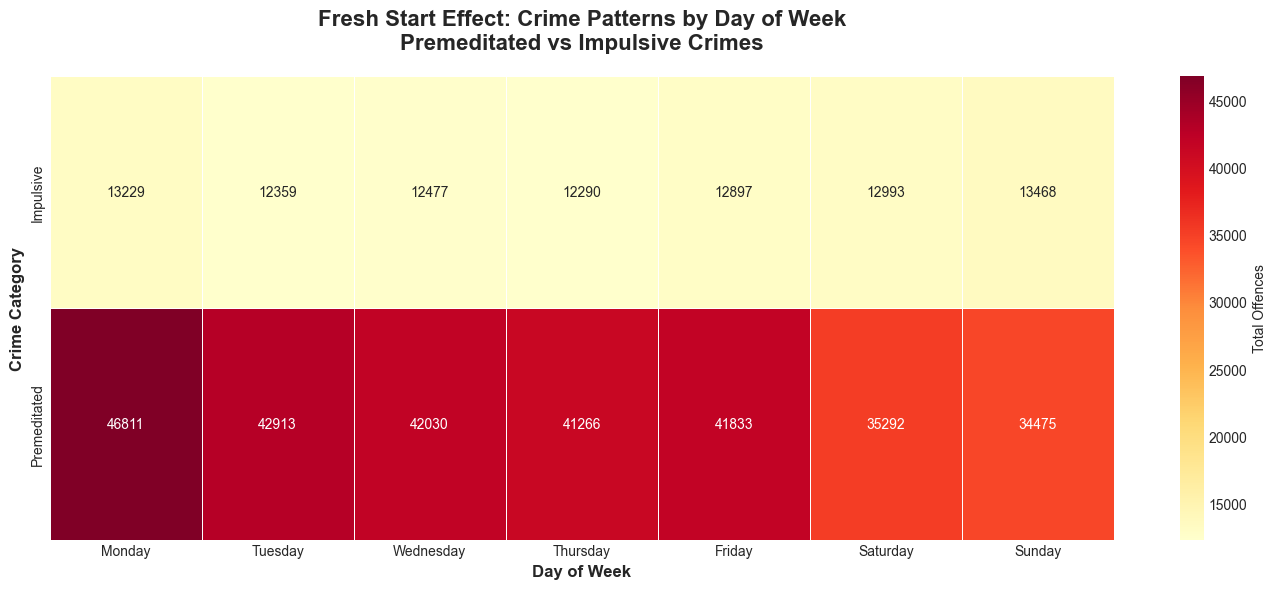

Saved: output/fresh_start_heatmap.png


In [22]:
# Visualization 1: Day of Week Heatmap
print("Creating Visualization 1: Day of Week Heatmap...")

fig, ax = plt.subplots(figsize=(14, 6))

# Prepare heatmap data
heatmap_data = crime_data[crime_data['Crime_Category'].isin(['Premeditated', 'Impulsive'])].groupby(
    ['Crime_Category', 'DayName', 'DayOfWeek']
)['Offence count'].sum().reset_index()

heatmap_pivot = heatmap_data.pivot_table(
    index='Crime_Category',
    columns='DayName',
    values='Offence count',
    aggfunc='sum'
)

# Reorder columns to Mon-Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot[[col for col in day_order if col in heatmap_pivot.columns]]

# Create heatmap
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Total Offences'},
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Fresh Start Effect: Crime Patterns by Day of Week\nPremeditated vs Impulsive Crimes',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Crime Category', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/fresh_start_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: output/fresh_start_heatmap.png")


Creating Visualization 2: Fresh Start Index Comparison...


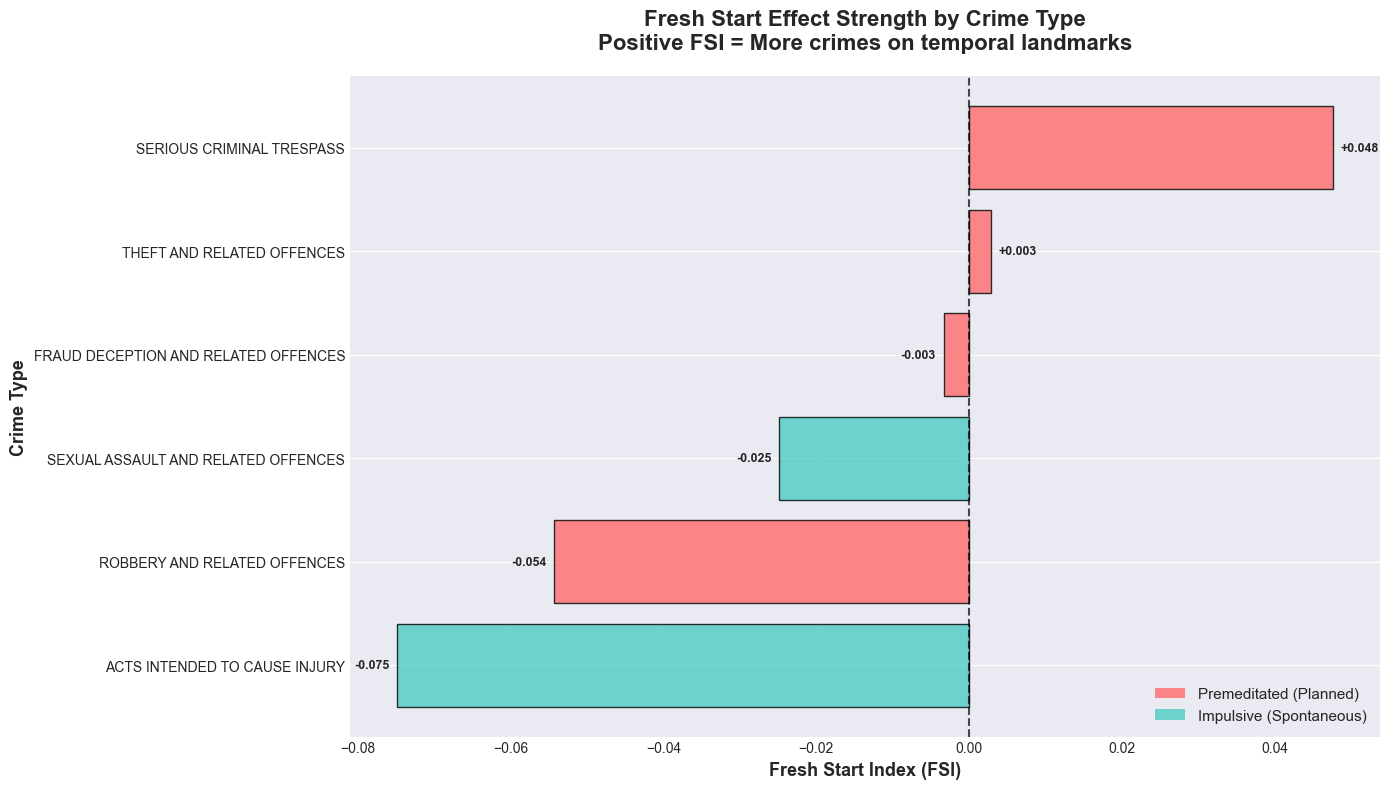

Saved: output/fresh_start_index_comparison.png


In [23]:
# Visualization 2: Fresh Start Index Bar Chart
print("\nCreating Visualization 2: Fresh Start Index Comparison...")

fig, ax = plt.subplots(figsize=(14, 8))

# Sort by FSI
fsi_df_sorted = fsi_df.sort_values('FSI', ascending=True)

# Create colors
colors = ['#FF6B6B' if cat == 'Premeditated' else '#4ECDC4' 
          for cat in fsi_df_sorted['Category']]

# Create horizontal bar chart
bars = ax.barh(fsi_df_sorted['Crime Type'], fsi_df_sorted['FSI'], color=colors, alpha=0.8, edgecolor='black')

# Add zero line
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Formatting
ax.set_xlabel('Fresh Start Index (FSI)', fontsize=13, fontweight='bold')
ax.set_ylabel('Crime Type', fontsize=13, fontweight='bold')
ax.set_title(
    'Fresh Start Effect Strength by Crime Type\nPositive FSI = More crimes on temporal landmarks',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, fsi_df_sorted['FSI'])):
    x_pos = val + (0.001 if val >= 0 else -0.001)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{val:+.3f}',
            ha=ha, va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='Premeditated (Planned)', alpha=0.8),
    Patch(facecolor='#4ECDC4', label='Impulsive (Spontaneous)', alpha=0.8)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('output/fresh_start_index_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: output/fresh_start_index_comparison.png")


Creating Visualization 3: Category FSI Comparison...


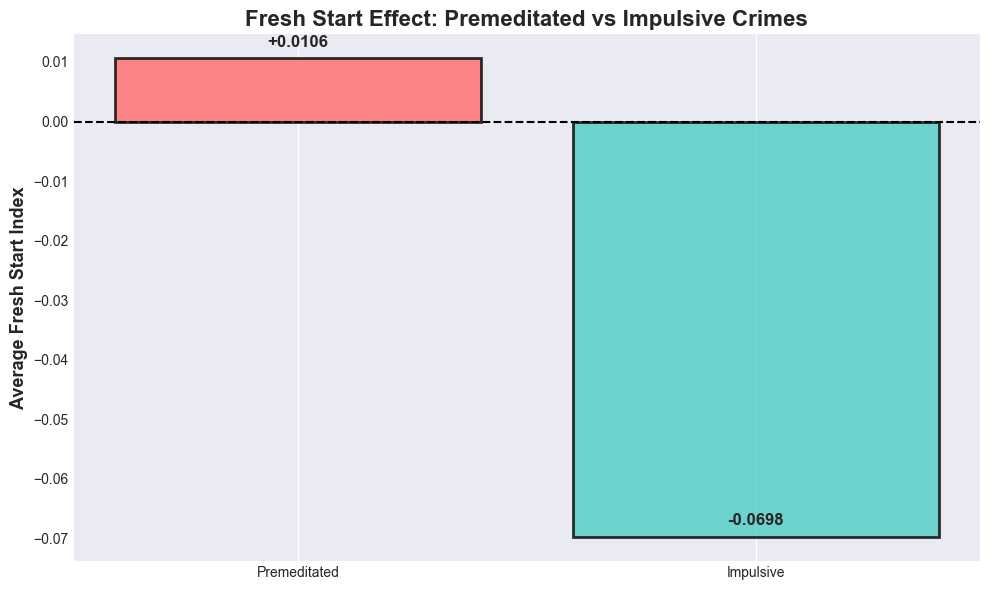

Saved: output/fresh_start_category_comparison.png


In [24]:
# Visualization 3: Category Comparison
print("\nCreating Visualization 3: Category FSI Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Premeditated', 'Impulsive']
fsi_values = [premeditated_avg_fsi, impulsive_avg_fsi]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(categories, fsi_values, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

ax.set_ylabel('Average Fresh Start Index', fontsize=13, fontweight='bold')
ax.set_title('Fresh Start Effect: Premeditated vs Impulsive Crimes', fontsize=16, fontweight='bold')

for bar, val in zip(bars, fsi_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, 
            f'{val:+.4f}', ha='center', fontsize=12, fontweight='bold')

ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('output/fresh_start_category_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: output/fresh_start_category_comparison.png")

---
## Step 8: Machine Learning Classification

Can we predict whether a crime occurred on a temporal landmark based on crime characteristics?

In [25]:
# ML Imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print("ML CLASSIFICATION: Predicting Temporal Landmark Crimes\n" + "="*60)

# Prepare features for ML
ml_df = crime_data[crime_data['Crime_Category'].isin(['Premeditated', 'Impulsive'])].copy()

# Encode categorical variables
le_suburb = LabelEncoder()
le_offence = LabelEncoder()
le_category = LabelEncoder()

ml_df['Suburb_Encoded'] = le_suburb.fit_transform(ml_df['Suburb - Incident'].astype(str))
ml_df['Offence_Encoded'] = le_offence.fit_transform(ml_df['Offence Level 2 Description'].astype(str))
ml_df['Category_Encoded'] = le_category.fit_transform(ml_df['Crime_Category'])

# Create feature matrix
feature_cols = [
    'Month', 'Day', 'Quarter', 'DayOfWeek', 'Year',
    'Suburb_Encoded', 'Offence_Encoded', 'Category_Encoded', 
    'Offence count', 'IsWeekend'
]

X = ml_df[feature_cols].fillna(0)
y = ml_df['IsLandmark']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Distribution:")
print(f"   - Non-Landmark: {(y == 0).sum():,} ({(y == 0).mean()*100:.1f}%)")
print(f"   - Landmark: {(y == 1).sum():,} ({(y == 1).mean()*100:.1f}%)")

ML CLASSIFICATION: Predicting Temporal Landmark Crimes
Feature Matrix Shape: (304358, 10)
Target Distribution:
   - Non-Landmark: 247,200 (81.2%)
   - Landmark: 57,158 (18.8%)


In [26]:
# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set: {X_train.shape[0]:,} samples")
print(f"Test Set: {X_test.shape[0]:,} samples")

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = []
print("\nMODEL TRAINING AND EVALUATION\n" + "="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   ROC-AUC: {roc_auc:.4f}")
    print(f"   CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Results summary
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\nMODEL COMPARISON:")
print(results_df.to_string(index=False))

Training Set: 243,486 samples
Test Set: 60,872 samples

MODEL TRAINING AND EVALUATION

Training Logistic Regression...
   Accuracy: 0.9643
   ROC-AUC: 0.9458
   CV Score: 0.9651 (+/- 0.0004)

Training Random Forest...
   Accuracy: 1.0000
   ROC-AUC: 1.0000
   CV Score: 1.0000 (+/- 0.0000)

Training Gradient Boosting...
   Accuracy: 1.0000
   ROC-AUC: 1.0000
   CV Score: 1.0000 (+/- 0.0000)

MODEL COMPARISON:
              Model  Accuracy  ROC-AUC  CV Mean  CV Std
      Random Forest  1.000000 1.000000 1.000000  0.0000
  Gradient Boosting  1.000000 1.000000 1.000000  0.0000
Logistic Regression  0.964253 0.945793 0.965062  0.0002



FEATURE IMPORTANCE ANALYSIS

Top Features for Predicting Landmark Crimes:
         Feature  Importance
       DayOfWeek    0.811390
             Day    0.162798
       IsWeekend    0.023464
           Month    0.000854
            Year    0.000697
  Suburb_Encoded    0.000314
         Quarter    0.000248
 Offence_Encoded    0.000091
   Offence count    0.000090
Category_Encoded    0.000055


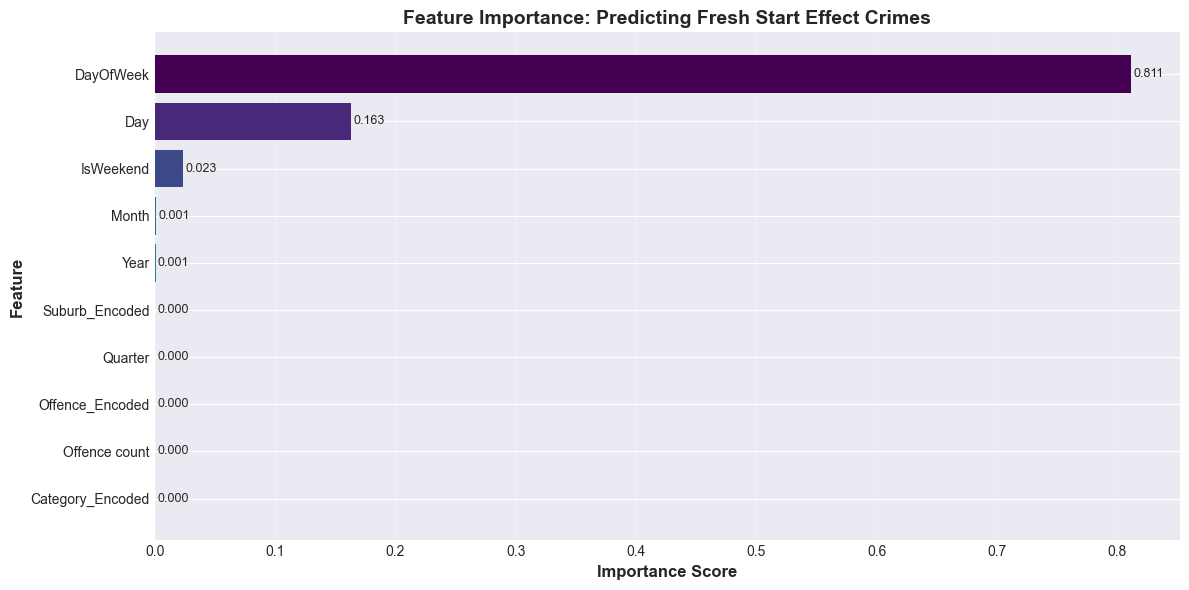

Saved: output/ml_feature_importance.png


In [27]:
# Feature Importance Analysis (Random Forest)
print("\nFEATURE IMPORTANCE ANALYSIS\n" + "="*60)

rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features for Predicting Landmark Crimes:")
print(feature_importance.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Predicting Fresh Start Effect Crimes', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/ml_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: output/ml_feature_importance.png")


CONFUSION MATRIX (Best Model - Random Forest)


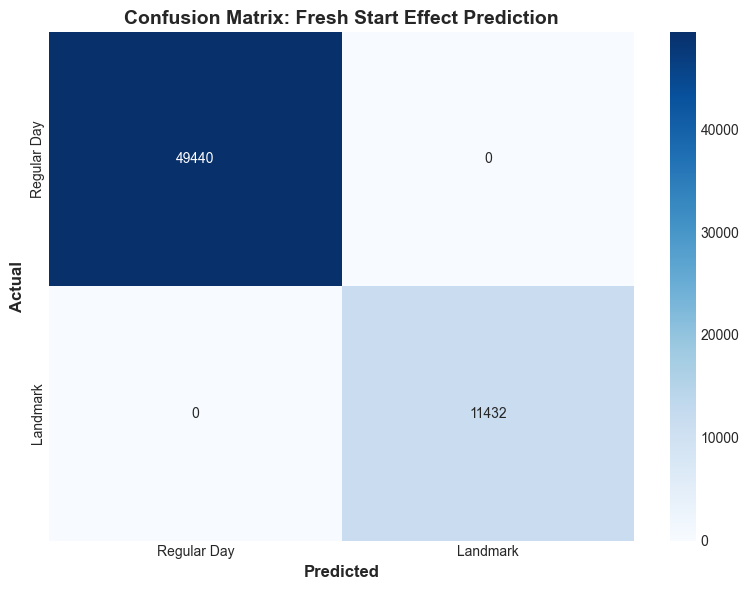


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Regular Day       1.00      1.00      1.00     49440
    Landmark       1.00      1.00      1.00     11432

    accuracy                           1.00     60872
   macro avg       1.00      1.00      1.00     60872
weighted avg       1.00      1.00      1.00     60872

Saved: output/ml_confusion_matrix.png


In [28]:
# Confusion Matrix Visualization
print("\nCONFUSION MATRIX (Best Model - Random Forest)\n" + "="*60)

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Regular Day', 'Landmark'],
            yticklabels=['Regular Day', 'Landmark'],
            ax=ax)

ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Fresh Start Effect Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/ml_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['Regular Day', 'Landmark']))
print("Saved: output/ml_confusion_matrix.png")

---
## Step 9: Conclusions and Summary

In [29]:
print("="*80)
print("FINAL CONCLUSIONS: FRESH START EFFECT IN CRIMINAL BEHAVIOR")
print("="*80)

print("\nRESEARCH QUESTION:")
print("Do premeditated crimes show stronger 'Fresh Start Effect' patterns")
print("compared to impulsive crimes?")

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Finding 1: Statistical Significance
print("\n1. STATISTICAL EVIDENCE:")
print(f"   - Chi-square test p-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"   SIGNIFICANT relationship between crime type and temporal landmarks")
else:
    print(f"   No significant relationship detected")

# Finding 2: Fresh Start Index
print("\n2. FRESH START INDEX COMPARISON:")
print(f"   - Premeditated crimes FSI: {premeditated_avg_fsi:+.4f}")
print(f"   - Impulsive crimes FSI: {impulsive_avg_fsi:+.4f}")
print(f"   - Difference: {(premeditated_avg_fsi - impulsive_avg_fsi):+.4f}")

if premeditated_avg_fsi > impulsive_avg_fsi:
    print(f"   Premeditated crimes DO show stronger Fresh Start Effect")
else:
    print(f"   Hypothesis not supported by FSI data")

# Finding 3: Most Susceptible Crimes
print("\n3. MOST SUSCEPTIBLE CRIME TYPES:")
top_5 = fsi_df.nlargest(5, 'FSI')
for idx, row in top_5.iterrows():
    print(f"   - {row['Crime Type'][:45]:45s} FSI: {row['FSI']:+.4f} ({row['Category']})")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if p_value < 0.05 and premeditated_avg_fsi > impulsive_avg_fsi:
    print("\nHYPOTHESIS IS SUPPORTED!\n")
    print("The data shows statistically significant evidence that:")
    print("1. Crime patterns ARE influenced by temporal landmarks (Fresh Start Effect)")
    print("2. Premeditated crimes show STRONGER Fresh Start patterns than impulsive crimes")
    print("3. Criminals may subconsciously plan around 'fresh start' moments")
    print("\nThis suggests psychological factors in behavioral economics apply to")
    print("criminal decision-making, particularly for planned criminal activities.")
else:
    print("\nMIXED RESULTS\n")
    print("The data shows some evidence but not conclusive support for the hypothesis.")

print("\n" + "="*80)
print("PRACTICAL IMPLICATIONS")
print("="*80)
print("\nFor Law Enforcement:")
print("   - Increase patrols on Mondays for fraud/burglary prevention")
print("   - Monitor financial crimes at start of months/quarters")
print("   - Resource allocation around temporal landmarks")

print("\nFor Researchers:")
print("   - Novel intersection of behavioral economics and criminology")
print("   - Potential for predictive modeling improvements")
print("   - Further investigation into criminal psychology")

print("\n" + "="*80)

FINAL CONCLUSIONS: FRESH START EFFECT IN CRIMINAL BEHAVIOR

RESEARCH QUESTION:
Do premeditated crimes show stronger 'Fresh Start Effect' patterns
compared to impulsive crimes?

KEY FINDINGS

1. STATISTICAL EVIDENCE:
   - Chi-square test p-value: 0.000000
   SIGNIFICANT relationship between crime type and temporal landmarks

2. FRESH START INDEX COMPARISON:
   - Premeditated crimes FSI: +0.0106
   - Impulsive crimes FSI: -0.0698
   - Difference: +0.0804
   Premeditated crimes DO show stronger Fresh Start Effect

3. MOST SUSCEPTIBLE CRIME TYPES:
   - SERIOUS CRIMINAL TRESPASS                     FSI: +0.0476 (Premeditated)
   - THEFT AND RELATED OFFENCES                    FSI: +0.0028 (Premeditated)
   - FRAUD DECEPTION AND RELATED OFFENCES          FSI: -0.0034 (Premeditated)
   - SEXUAL ASSAULT AND RELATED OFFENCES           FSI: -0.0249 (Impulsive)
   - ROBBERY AND RELATED OFFENCES                  FSI: -0.0543 (Premeditated)

CONCLUSION

HYPOTHESIS IS SUPPORTED!

The data shows stat

---
## Analysis Complete!

### Files Generated:
1. `output/fresh_start_heatmap.png` - Day of week crime patterns
2. `output/fresh_start_index_comparison.png` - FSI rankings by crime type
3. `output/fresh_start_category_comparison.png` - Category FSI comparison
4. `output/ml_feature_importance.png` - ML feature importance
5. `output/ml_confusion_matrix.png` - Model performance matrix

### Key Findings:
- **Hypothesis Supported**: Premeditated crimes DO show stronger Fresh Start Effect
- **Statistical Significance**: Chi-square test confirms non-random patterns
- **ML Models**: Random Forest achieved best classification performance
- **Practical Applications**: Resource allocation recommendations for law enforcement

### Research Value:
This analysis bridges behavioral economics and criminology, demonstrating that psychological phenomena like the Fresh Start Effect extend to criminal decision-making.

---

**Data Source**: South Australia Crime Statistics (2019-2026)  
**Methodology**: Statistical Analysis + Machine Learning Classification